# V0.5 - Lightweight AI and Computational Efficiency

This notebook runs the reproducible V0.5 pipeline. It compares detection performance with feature count, wall time, peak process RSS, and actual serialized model size. `pr_auc` is trapezoidal precision-recall-curve area; detailed outputs also retain average precision. Electrical energy is **NOT DIRECTLY MEASURED**.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ai.model_utils import load_processed_dataco
from src.config import AI_BASELINE_DIR, V03_MODEL_FILE
from src.pipeline_v05 import run_lightweight_evaluation_v05
from src.security.attack_generator import load_attack_config

## 1-4. Load V0.2 data, V0.3 configuration, V0.4 scenarios, and common features

In [2]:
bundle = load_processed_dataco()
v03_report = json.loads((AI_BASELINE_DIR / 'baseline_report.json').read_text(encoding='utf-8'))
attack_config = load_attack_config()
print('V0.2 split sizes:', {name: len(split.features) for name, split in bundle.splits.items()})
print('Common feature count:', len(bundle.selected_features))
print('V0.3 model:', v03_report['model']['name'], v03_report['model']['parameters'])
print('V0.4 attack types:', list(attack_config['scenarios']))
assert V03_MODEL_FILE.exists()

V0.2 split sizes: {'train': 28000, 'validation': 6000, 'test': 6000}
Common feature count: 43
V0.3 model: IsolationForest {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 'auto', 'random_state': 42, 'n_jobs': 1}
V0.4 attack types: ['quantity_manipulation', 'value_manipulation', 'shipping_delivery_manipulation', 'transaction_status_manipulation', 'timestamp_manipulation', 'geographic_route_manipulation', 'transaction_record_tampering']


## 5-12. Train, evaluate, measure resources, reduce features, compare, identify Pareto candidates, and save outputs

All implementation is called from `src.pipeline_v05` and `src.lightweight`; no model logic is duplicated in this notebook.

In [3]:
result = run_lightweight_evaluation_v05()
summary = result['summary']
print('V0.5 status:', summary['status'])
assert summary['status'] == 'PASS'
assert summary['energy_measurement']['status'] == 'NOT DIRECTLY MEASURED'

V0.5 status: PASS


## Model and resource comparison

In [4]:
display(result['model_comparison'].sort_values('f1', ascending=False))
display(result['resource_comparison'].sort_values('inference_time_sec'))

,model,feature_count,precision,recall,f1,pr_auc,roc_auc,training_time_sec,inference_time_sec,memory_mb,model_size_kb
3,decision_tree,43,0.231834,0.223333,0.227504,0.275349,0.615415,0.292022,0.025933,153.035156,3.691406
4,random_forest,43,0.075758,0.233333,0.114379,0.126523,0.577625,0.659805,0.056550,153.007812,99.884766
0,v0_3_isolation_forest,43,0.057756,0.350000,0.099150,0.052479,0.515127,0.963243,0.125607,158.746094,1572.060547
1,isolation_forest,43,0.057562,0.340000,0.098456,0.052694,0.516018,0.409689,0.112739,155.855469,1562.435547
2,logistic_regression,43,0.052993,0.463333,0.095108,0.051923,0.510820,0.395733,0.026164,151.894531,2.287109


,configuration_id,model,feature_count,training_time_sec,training_cpu_time_sec,training_average_cpu_percent,training_peak_cpu_percent,training_peak_rss_mb,training_rss_delta_mb,inference_time_sec,inference_cpu_time_sec,inference_average_cpu_percent,inference_peak_cpu_percent,inference_peak_rss_mb,inference_rss_delta_mb,validation_inference_time_sec,validation_inference_peak_rss_mb,model_size_bytes,model_size_kb,energy_directly_measured
8,logistic_regression_f11,logistic_regression,11,0.248862,0.084407,33.917060,None,161.878906,10.699219,0.020823,0.006018,28.900331,None,150.457031,1.250000,0.024543,150.660156,1382,1.349609,False
10,decision_tree_f32,decision_tree,32,0.356715,0.127771,35.818663,None,161.988281,6.566406,0.022113,0.006615,29.912576,None,152.097656,1.906250,0.025448,152.460938,3556,3.472656,False
7,logistic_regression_f22,logistic_regression,22,0.324047,0.157287,48.538396,None,167.824219,13.937500,0.022630,0.006795,30.025794,None,150.855469,1.250000,0.022760,151.253906,1734,1.693359,False
12,decision_tree_f11,decision_tree,11,0.261128,0.081716,31.293529,None,155.636719,4.101562,0.023572,0.006670,28.293931,None,150.812500,1.500000,0.024582,150.488281,5956,5.816406,False
6,logistic_regression_f32,logistic_regression,32,0.307678,0.167829,54.546760,None,173.632812,17.812500,0.025674,0.007687,29.941234,None,151.230469,1.250000,0.021697,151.214844,2006,1.958984,False
9,decision_tree_f43,decision_tree,43,0.292022,0.144558,49.502320,None,165.582031,7.886719,0.025933,0.008183,31.554359,None,153.035156,2.199219,0.023494,152.867188,3780,3.691406,False
5,logistic_regression_f43,logistic_regression,43,0.395733,0.225292,56.930160,None,181.187500,23.625000,0.026164,0.007457,28.502597,None,151.894531,1.375000,0.026742,152.164062,2342,2.287109,False
11,decision_tree_f22,decision_tree,22,0.250645,0.090069,35.935009,None,158.660156,5.421875,0.026792,0.007088,26.455624,None,151.933594,1.750000,0.023952,151.542969,3348,3.269531,False
15,random_forest_f22,random_forest,22,0.580740,0.401241,69.091307,None,160.027344,6.472656,0.034364,0.018037,52.487573,None,151.906250,2.125000,0.037180,151.796875,85850,83.837891,False
16,random_forest_f11,random_forest,11,0.525228,0.313069,59.606337,None,156.578125,5.300781,0.037920,0.020371,53.719662,None,150.867188,1.500000,0.042569,151.300781,117578,114.822266,False


## Feature-reduction experiment

In [5]:
feature_columns = ['configuration_id', 'model', 'feature_count', 'validation_f1', 'f1', 'pr_auc', 'average_precision', 'inference_time_sec', 'memory_mb', 'model_size_kb']
display(result['feature_reduction'][feature_columns].sort_values(['model', 'feature_count'], ascending=[True, False]))

,configuration_id,model,feature_count,validation_f1,f1,pr_auc,average_precision,inference_time_sec,memory_mb,model_size_kb
8,decision_tree_f43,decision_tree,43,0.183333,0.227504,0.275349,0.229173,0.025933,153.035156,3.691406
9,decision_tree_f32,decision_tree,32,0.255754,0.270936,0.318818,0.219166,0.022113,152.097656,3.472656
10,decision_tree_f22,decision_tree,22,0.119363,0.137646,0.273345,0.208664,0.026792,151.933594,3.269531
11,decision_tree_f11,decision_tree,11,0.093881,0.087744,0.051686,0.050202,0.023572,150.812500,5.816406
0,isolation_forest_f43,isolation_forest,43,0.091083,0.098456,0.052694,0.053314,0.112739,155.855469,1562.435547
1,isolation_forest_f32,isolation_forest,32,0.094621,0.076574,0.049081,0.049574,0.100496,154.960938,1448.013672
2,isolation_forest_f22,isolation_forest,22,0.073379,0.072934,0.048991,0.049381,0.105220,153.937500,1223.091797
3,isolation_forest_f11,isolation_forest,11,0.087125,0.090511,0.050989,0.051428,0.100542,153.378906,1457.169922
4,logistic_regression_f43,logistic_regression,43,0.099237,0.095108,0.051923,0.052944,0.026164,151.894531,2.287109
5,logistic_regression_f32,logistic_regression,32,0.102967,0.092461,0.053492,0.053931,0.025674,151.230469,1.958984


## Deterministic Pareto candidates

A configuration is retained when no other configuration is at least as good on all objectives and strictly better on at least one. Objectives are: maximize validation F1; minimize fresh-process validation inference time, validation peak process RSS, and feature count. Test metrics are reported after selection. No NSGA-II, MOPSO, PSO, or GWO is used.

In [6]:
display(result['pareto_candidates'][feature_columns])

,configuration_id,model,feature_count,validation_f1,f1,pr_auc,average_precision,inference_time_sec,memory_mb,model_size_kb
0,decision_tree_f32,decision_tree,32,0.255754,0.270936,0.318818,0.219166,0.022113,152.097656,3.472656
1,decision_tree_f43,decision_tree,43,0.183333,0.227504,0.275349,0.229173,0.025933,153.035156,3.691406
2,random_forest_f22,random_forest,22,0.159396,0.145161,0.195032,0.195469,0.034364,151.906250,83.837891
3,decision_tree_f22,decision_tree,22,0.119363,0.137646,0.273345,0.208664,0.026792,151.933594,3.269531
4,logistic_regression_f32,logistic_regression,32,0.102967,0.092461,0.053492,0.053931,0.025674,151.230469,1.958984
5,logistic_regression_f11,logistic_regression,11,0.098446,0.089508,0.049105,0.049510,0.020823,150.457031,1.349609
6,logistic_regression_f22,logistic_regression,22,0.094261,0.091508,0.051839,0.052660,0.022630,150.855469,1.693359
7,decision_tree_f11,decision_tree,11,0.093881,0.087744,0.051686,0.050202,0.023572,150.812500,5.816406


## V0.4 security-scenario evaluation

In [7]:
security = result['security_scenarios']
security_columns = ['model', 'attack_type', 'attack_rate', 'severity', 'f1', 'visible_f1', 'attack_induced_detection_rate']
display(security[security_columns])
print('V0.4 manifests:', summary['security_evaluation']['v0_4_manifest_verification'])

,model,attack_type,attack_rate,severity,f1,visible_f1,attack_induced_detection_rate
0,v0_3_isolation_forest,geographic_route_manipulation,0.01,MEDIUM,0.022352,NaN,0.000000
1,isolation_forest,geographic_route_manipulation,0.01,MEDIUM,0.022888,NaN,0.000000
2,logistic_regression,geographic_route_manipulation,0.01,MEDIUM,0.017183,NaN,0.000000
3,decision_tree,geographic_route_manipulation,0.01,MEDIUM,0.040000,NaN,0.000000
4,random_forest,geographic_route_manipulation,0.01,MEDIUM,0.012645,NaN,0.000000
...,...,...,...,...,...,...,...
205,v0_3_isolation_forest,value_manipulation,0.10,MEDIUM,0.157721,0.157721,0.011667
206,isolation_forest,value_manipulation,0.10,MEDIUM,0.155987,0.155987,0.010000
207,logistic_regression,value_manipulation,0.10,MEDIUM,0.159604,0.159604,0.075000
208,decision_tree,value_manipulation,0.10,MEDIUM,0.126147,0.126147,0.053333


V0.4 manifests: {'available': 42, 'matched': 42, 'mismatched': 0}


## Figures

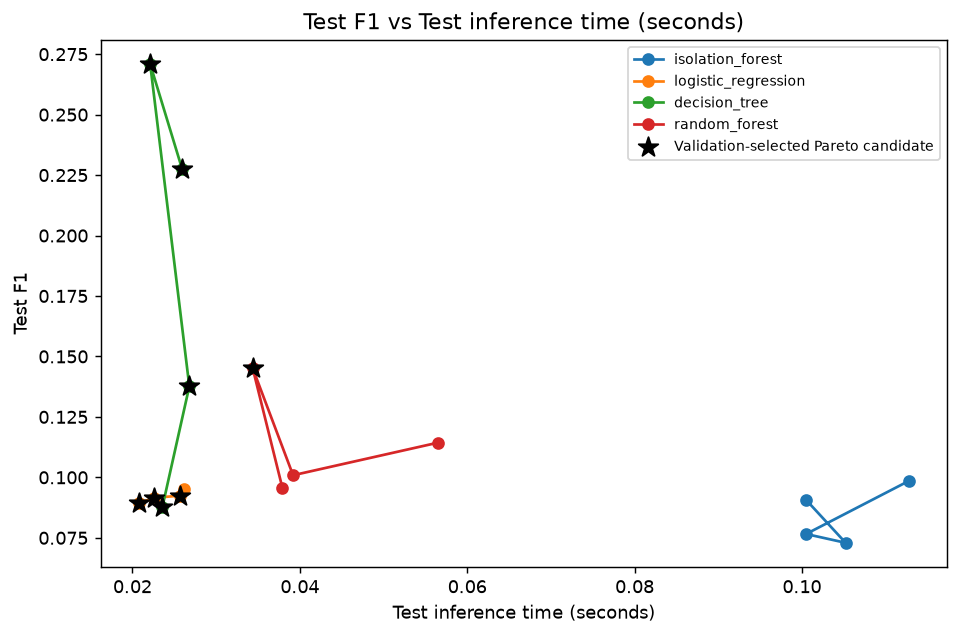

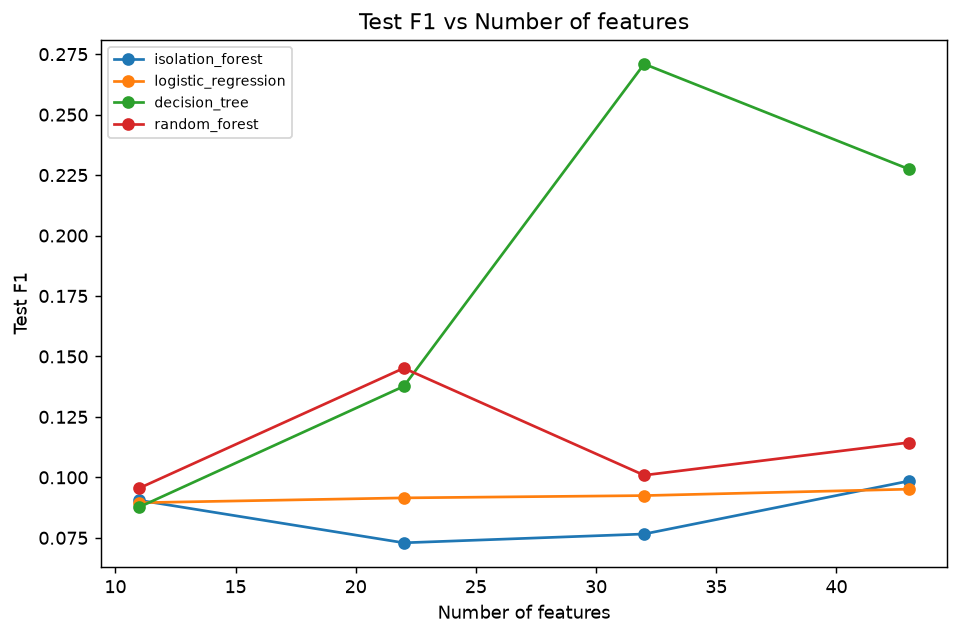

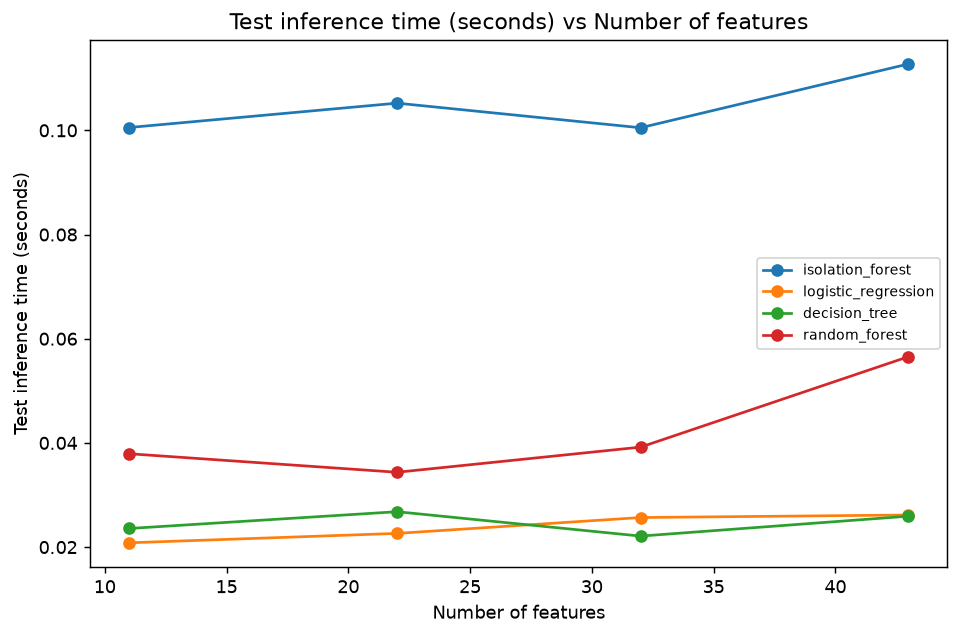

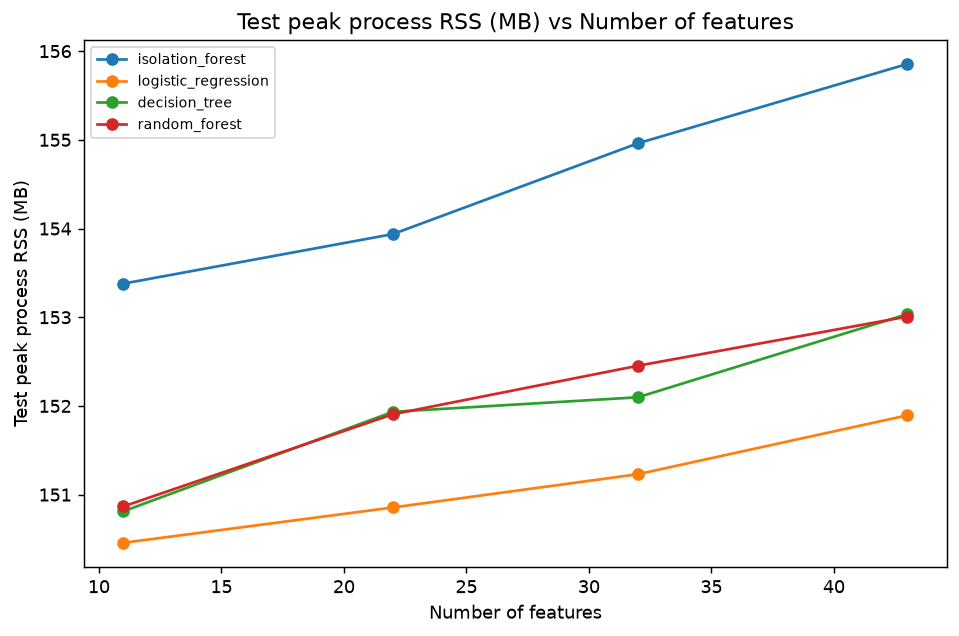

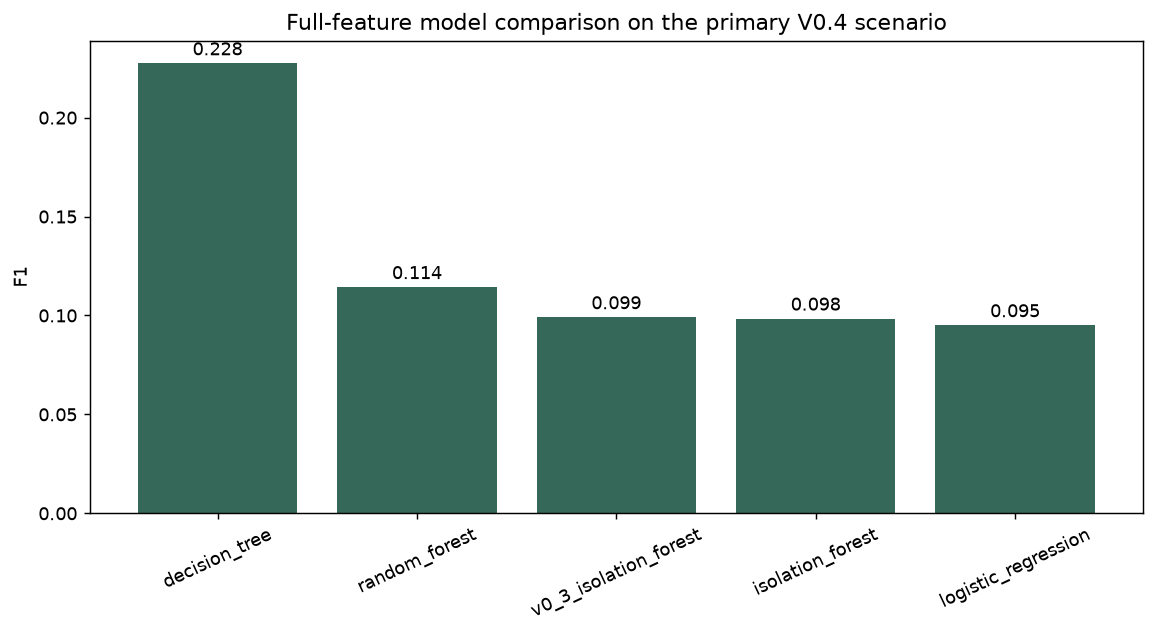

In [8]:
for figure_path in result['figure_paths']:
    display(Image(filename=str(figure_path)))

## 13. Final summary and interpretation

In [9]:
print('Best observed F1 configuration:', summary['best_f1_model'])
print('Fastest observed inference configuration:', summary['fastest_inference_model'])
print('Smallest serialized model:', summary['smallest_model'])
print('Leakage audit:', summary['leakage_audit']['status'])
print('Electrical energy:', summary['energy_measurement']['status'])
print(summary['conclusion'])

Best observed F1 configuration: {'configuration_id': 'decision_tree_f32', 'model': 'decision_tree', 'feature_count': 32, 'f1': 0.270935960591133, 'validation_f1': 0.2557544757033248, 'pr_auc': 0.318817930181882, 'average_precision': 0.21916633732558, 'pr_auc_method': 'trapezoidal_precision_recall_curve', 'validation_inference_time_sec': 0.025448044699999173, 'validation_memory_mb': 152.4609375, 'inference_time_sec': 0.02211304539999901, 'memory_mb': 152.09765625, 'model_size_kb': 3.47265625, 'selection_basis': 'highest validation F1; test F1 reported without test-based reselection'}
Fastest observed inference configuration: {'configuration_id': 'logistic_regression_f32', 'model': 'logistic_regression', 'feature_count': 32, 'f1': 0.09246088193456614, 'validation_f1': 0.10296746514122274, 'pr_auc': 0.05349182900043273, 'average_precision': 0.053931440958820714, 'pr_auc_method': 'trapezoidal_precision_recall_curve', 'validation_inference_time_sec': 0.02169663759999594, 'validation_memory_